imports

In [6]:
import os
import sys

sys.path.append("..")

from cleanroom_cfd.config import SimulationConfig
from cleanroom_cfd.geometry import load_room_from_svg
from cleanroom_cfd.entities import Entity
from cleanroom_cfd.initial_conditions import warmup_bubble
from cleanroom_cfd.simulation import compute_time_step, make_flow_obstacle, cfd_step
from cleanroom_cfd.visualization import animate_simulation
import numpy as np

config and geometry

In [30]:
cfg = SimulationConfig()

svg_path = "../assets/Feynmann room_inked_good.svg"
geom = load_room_from_svg(svg_path, cfg.res)

svg_width_m = geom["svg_width_m"]
svg_height_m = geom["svg_height_m"]
grid_w = geom["grid_w"]
grid_h = geom["grid_h"]
is_obstacle = geom["is_obstacle"]

dx = 1.0 / cfg.res

hs_x = int(cfg.hotspot_x_m * cfg.res)
hs_y = int(cfg.hotspot_y_m * cfg.res)

y_start = max(1, int((cfg.y_sock_m - cfg.sock_thickness_m) * cfg.res))
y_end = min(grid_h - 2, int((cfg.y_sock_m + cfg.sock_thickness_m) * cfg.res))
y_mid = (y_start + y_end) // 2

src_half = cfg.source_half_thickness_cells
src_y0 = max(1, y_mid - src_half)
src_y1 = min(grid_h - 1, y_mid + src_half)

entities_list = [
    # Machine 1: Left side (x=1.0, y=2.0)
    Entity("heat_source_short", x_m=1.0, y_m=2.0, width_m=0.8, height_m=0.8, id_name="left"),
    
    # Machine 2: Right side (x=7.5, y=1.5)
    Entity("heat_source_short", x_m=7.5, y_m=1.5, width_m=1.0, height_m=0.6, id_name="right"),
    
    # Human 1: Bottom and moves to the right
    Entity("human", x_m=0.5, y_m=1.5, width_m=0.4, height_m=0.4, id_name="scientist_paco"),
    
    # Human 2: The new one that starts at the down and leaves (x=2.5, y=7.0)
    Entity("human", x_m=2.5, y_m=5.0, width_m=0.4, height_m=0.4, id_name="scientist_maria")
]

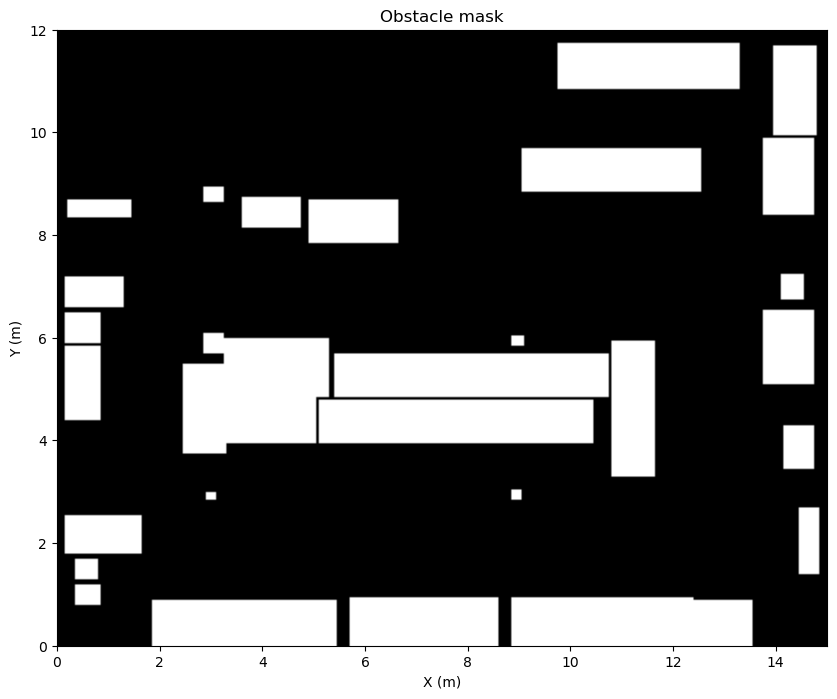

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.imshow(is_obstacle, origin="lower", extent=[0, svg_width_m, 0, svg_height_m], cmap="gray")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.title("Obstacle mask")
plt.show()

initial fields

In [27]:
thermal_grid = warmup_bubble(
    grid_h, grid_w, is_obstacle, hs_x, hs_y,
    cfg.alpha_heat, dx, cfg.warmup_steps, cfg.bubble_r
)

thermal_grid[src_y0:src_y1, 1:-1] = (
    0.65 * thermal_grid[src_y0:src_y1, 1:-1] + 0.35 * cfg.supply_temp
)

sock_tracer = np.zeros((grid_h, grid_w))
sock_tracer[src_y0:src_y1, 1:-1] = 0.9

u_vel = np.zeros((grid_h, grid_w))
v_vel = np.zeros((grid_h, grid_w))
p = np.zeros((grid_h, grid_w))

flow_obstacle = make_flow_obstacle(is_obstacle, src_y0, src_y1)
dt = compute_time_step(dx, cfg.sock_speed, cfg.alpha_heat, cfg.nu_eff)
substeps_per_frame = max(1, int(cfg.target_time / (cfg.frames * dt)))

print("dt =", dt)
print("substeps_per_frame =", substeps_per_frame)

dt = 0.008333333333333335
substeps_per_frame = 43


step function wrapper

In [ ]:
def step_fn(T, tracer, u, v, p):

    # Dynamic logic
    # Move the humans a bit every step
    for ent in entities_list:
        if ent.id_name == "scientist_paco":
            ent.x += 0.001 
             

        if ent.id_name == "scientist_maria":
            ent.y += 0.0015 # Maria walks upwards faster
            if ent.y > 8.0: ent.is_active = False
            
    return cfd_step(
        T, tracer, u, v, p,
        dx=dx,
        dt=dt,
        entities_list=entities_list,
        is_obstacle=is_obstacle,
        res=cfg.res,
        src_y0=src_y0,
        src_y1=src_y1,
        hs_x=hs_x,
        hs_y=hs_y,
        bubble_r=cfg.bubble_r,
        alpha_heat=cfg.alpha_heat,
        nu_eff=cfg.nu_eff,
        rho=cfg.rho,
        beta_b=cfg.beta_b,
        g=cfg.g,
        T_ref=cfg.T_ref,
        sock_speed=cfg.sock_speed,
        supply_temp=cfg.supply_temp,
        smoke_diff=cfg.smoke_diff,
        pressure_iters=cfg.pressure_iters,
        max_speed=cfg.max_speed
    )

animate

In [32]:
anim = animate_simulation(
    thermal_grid, sock_tracer, u_vel, v_vel, p,
    step_fn=step_fn,
    frames=cfg.frames,
    substeps_per_frame=substeps_per_frame,
    svg_width_m=svg_width_m,
    svg_height_m=svg_height_m,
    is_obstacle=is_obstacle,
    y_sock_m=cfg.y_sock_m,
    sock_thickness_m=cfg.sock_thickness_m,
    hs_x_m=cfg.hotspot_x_m,
    hs_y_m=cfg.hotspot_y_m,
    v_sock_target=cfg.sock_speed,
    T_supply=cfg.supply_temp,
    dt=dt
)